# 🔎 07_explorador_squad2 — Explorador dos containers da Squad 2
**Squad 2 · Dupla 3** · ferramenta de consulta, **somente leitura** (não grava, não move e não apaga nada)

Use os controles no topo do notebook para escolher o que explorar e rode as etapas desejadas de novo após mudar um controle.

| Controle | Para quê |
|---|---|
| `escopo` | só os seus dados (`ecommerce_pedidos`) ou a squad inteira |
| `container` | `squad2` (camadas) ou `raw` (origem) |
| `pasta` | ponto de partida da exploração (vazio = raiz do container) |
| `profundidade` | quantos níveis de pasta resumir na Etapa 2 |
| `contar_linhas` | conta as linhas de cada tabela Delta na Etapa 3 (mais lento) |
| `tabela` | tabela Delta inspecionada na Etapa 4 (caminho dentro do container) |
| `arquivo_json` | anotação de `metadata/` exibida na Etapa 5 |
| `limite` | linhas da amostra e commits do histórico |

**Parte A — Explorar** (segue os controles)

| Etapa | Conteúdo |
|---|---|
| 1 | Configuração e controles |
| 2 | Inventário de pastas: arquivos, tamanho e última modificação |
| 3 | Tabelas Delta encontradas |
| 4 | Inspeção de uma tabela: schema, partições, amostra e histórico de gravações |
| 5 | Anotações em `metadata/` |

**Parte B — Validar os dados enviados** (sempre sobre `ecommerce_pedidos`, independe dos controles)

| Etapa | Pergunta |
|---|---|
| 6 | Os números fecham de uma camada para a outra (raw → Bronze → Silver + quarentena → SQL Server → Gold)? |
| 7 | A Bronze respeita o contrato e a regra 2? |
| 8 | A Silver só tem pedidos válidos e a quarentena só reprovados, sem sobreposição? |
| 9 | A Gold está coerente com a Silver e consigo mesma? |
| 10 | Os clientes dos pedidos existem na tabela de clientes da squad? (informativo) |
| 11 | Veredito da validação |

## Etapa 1 — Configuração e controles
**Faz:** carrega o `00_setup_config` em modo rápido, cria os controles e escolhe o container.
**Valida:** acesso ao container e à pasta escolhidos.

In [0]:
VALIDACAO_COMPLETA = False

In [0]:
%run ./00_setup_config

# ⚙️ 00_setup_config — Configuração central
**Squad 2 · Dupla 3 · `ecommerce_pedidos`**

Prepara endereços, credenciais, conexões e funções usadas por todo o pipeline. **Não lê nem grava pedidos.**

Cada etapa **faz o trabalho e valida em seguida**: ✅ ok · ⚠️ aviso (segue) · ❌ erro (para e explica).

**Uso nos outros notebooks** (duas células; o `%run` fica sozinho):
```
VALIDACAO_COMPLETA = False
```
```
%run ./00_setup_config
```
Dependências em **Environment → Dependencies**: `azure-identity`, `azure-storage-file-datalake`.

## Etapa 1 — Ambiente e endereços
**Faz:** cria a função `checar` e guarda os nomes fixos do projeto.
**Valida:** se está no Databricks e se origem e destino são containers diferentes.

Modo de validação: RÁPIDA
✅ Rodando no Databricks
✅ Origem (raw) e destino (squad2) separados


## Etapa 2 — Credenciais
**Faz:** busca as 7 chaves no Secret Scope. Ficam só na memória (aparecem como `[REDACTED]` se impressas).
**Valida:** se o cofre existe, se nenhuma chave falta e se o host do SQL tem o formato certo.

✅ Cofre 'mercadata-ecommerce-pedidos' encontrado
✅ 7 credenciais carregadas (valores ocultos)
✅ SQL_HOST no formato do Azure SQL


...

✅ url_origem OK
✅ tabela_delta_existe OK (Bronze já existe)
✅ ler_metadata OK (None para anotação inexistente)
✅ versao_delta OK (Bronze na versão 43)
✅ trava_ativa OK (orquestrador parado)


## Etapa 6 — Funções do SQL Server
**Faz:** cria as funções de gravar e consultar o banco. Gravação pelo conector `sqlserver` (o `jdbc` é bloqueado no Serverless); leitura pelo `jdbc`.
**Valida:** se toda tabela recebe o schema `squad2`.

✅ Tabelas SQL vão para o schema 'squad2'


## Etapa 7 — Teste completo (só ao rodar este notebook direto)
**Faz e valida:** varre o `raw` · lê o micro-lote mais recente e confere colunas e tipos (regra 1) · grava e relê em `metadata/` · `SELECT 1` no SQL Server · confere se o schema `squad2` existe no banco.
No modo rápido (`%run`), é pulada. No fim, limpa as variáveis temporárias.

Teste completo pulado (modo rápido).
⚙️ 00_setup_config pronto para uso


In [0]:
from functools import reduce
import matplotlib.pyplot as plt
from pyspark.sql import functions as F

# Controles no topo do notebook (criados uma vez; depois só leem o valor escolhido)
dbutils.widgets.dropdown("escopo", TABELA, [TABELA, "squad inteira"])
dbutils.widgets.dropdown("container", CONTAINER_SQUAD, [CONTAINER_SQUAD, CONTAINER_ORIGEM])
dbutils.widgets.text("pasta", "")
dbutils.widgets.dropdown("profundidade", "2", ["1", "2", "3", "4"])
dbutils.widgets.dropdown("contar_linhas", "sim", ["sim", "não"])
dbutils.widgets.text("tabela", f"bronze/{TABELA}")
dbutils.widgets.text("arquivo_json", f"metadata/{TABELA}/eda_raw.json")
dbutils.widgets.text("limite", "10")

SO_MEUS_DADOS = dbutils.widgets.get("escopo") == TABELA       # filtra caminhos que contêm ecommerce_pedidos
CONTAINER = dbutils.widgets.get("container")
PASTA = dbutils.widgets.get("pasta").strip("/")
PROFUNDIDADE = int(dbutils.widgets.get("profundidade"))
CONTAR_LINHAS = dbutils.widgets.get("contar_linhas") == "sim"
LIMITE = int(dbutils.widgets.get("limite") or 10)

fs = {CONTAINER_SQUAD: fs_squad, CONTAINER_ORIGEM: fs_origem}[CONTAINER]          # cliente SDK do container escolhido
BASE = {CONTAINER_SQUAD: BASE_SQUAD, CONTAINER_ORIGEM: BASE_ORIGEM}[CONTAINER]     # endereço Spark do container escolhido
url = lambda caminho: f"{BASE}/{caminho}".rstrip("/")

# ------------------------------ validação ------------------------------
try:
    next(iter(fs.get_paths(path=PASTA or None, recursive=False)), None)            # lê só o primeiro item: prova de acesso
    _erro = None
except Exception as erro:
    _erro = str(erro)[:200]
checar(_erro is None, f"Acesso a {CONTAINER}/{PASTA or ''}", f"Sem acesso a {CONTAINER}/{PASTA}: {_erro}")

✅ Acesso a squad2/


## Etapa 2 — Inventário de pastas
**Faz:** percorre a pasta escolhida uma única vez e resume cada subpasta até a profundidade escolhida: arquivos, tamanho e última modificação.
Com `escopo = ecommerce_pedidos`, mostra só os caminhos dos seus dados.
Pastas que contêm `_delta_log` são marcadas como tabela Delta.
**Valida:** se a pasta tem conteúdo.

✅ 1,302 arquivos · 10.07 MB · 12 tabelas Delta


grupo,arquivos,mb,ultima_modificacao,tabela_delta
bronze/ecommerce_pedidos,135,1.708,2026-10-08 19:23:32,sim
gold/ecommerce_pedidos,948,5.212,2026-10-08 19:24:13,sim
metadata/ecommerce_pedidos,17,0.072,2026-10-08 19:24:12,
quarantine/ecommerce_pedidos,91,1.307,2026-10-08 19:23:45,sim
silver/ecommerce_pedidos,111,1.775,2026-10-08 19:23:42,sim


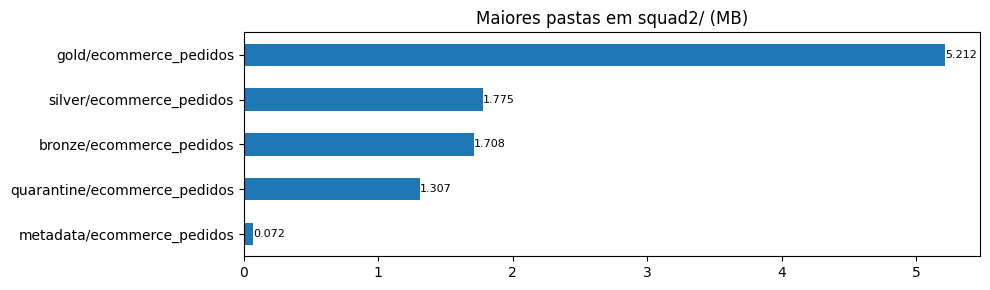

In [0]:
itens = pd.DataFrame([(p.name, p.is_directory, p.content_length or 0, p.last_modified)
                      for p in fs.get_paths(path=PASTA or None, recursive=True)],
                     columns=["caminho", "pasta", "bytes", "modificado"])

if SO_MEUS_DADOS:                                            # esconde as tabelas das outras duplas
    itens = itens[itens["caminho"].str.contains(TABELA, regex=False)]

# Caminho relativo ao ponto de partida e o grupo (subpasta) até a profundidade escolhida
inicio = len(PASTA) + 1 if PASTA else 0
itens["relativo"] = itens["caminho"].str[inicio:]
itens["grupo"] = itens["relativo"].str.split("/").str[:PROFUNDIDADE].str.join("/")
tabelas_delta = sorted({c.rsplit("/_delta_log", 1)[0] for c in itens.loc[itens["pasta"], "caminho"] if c.endswith("/_delta_log")})

arquivos = itens[~itens["pasta"]]
resumo_pastas = (arquivos.groupby("grupo")
                 .agg(arquivos=("caminho", "size"), mb=("bytes", lambda b: round(b.sum() / 1024**2, 3)),
                      ultima_modificacao=("modificado", "max")).reset_index().sort_values("grupo"))
resumo_pastas["tabela_delta"] = resumo_pastas["grupo"].map(
    lambda g: "sim" if any(t == f"{PASTA}/{g}".strip("/") or t.startswith(f"{PASTA}/{g}/".strip("/")) for t in tabelas_delta) else "")
resumo_pastas["ultima_modificacao"] = resumo_pastas["ultima_modificacao"].astype(str)

# ------------------------------ validação ------------------------------
checar(len(arquivos) > 0, f"{len(arquivos):,} arquivos · {arquivos['bytes'].sum() / 1024**2:,.2f} MB · {len(tabelas_delta)} tabelas Delta",
       f"Nenhum arquivo em {CONTAINER}/{PASTA}", parar=False)

# ------------------------------ resultado ------------------------------
display(resumo_pastas) if len(resumo_pastas) else print("Pasta vazia.")   # display() não aceita tabela vazia
if len(resumo_pastas):
    top = resumo_pastas.nlargest(15, "mb").sort_values("mb")
    ax = top.plot.barh(x="grupo", y="mb", figsize=(10, max(3, len(top) * 0.4)), legend=False,
                       title=f"Maiores pastas em {CONTAINER}/{PASTA} (MB)")
    ax.bar_label(ax.containers[0], fmt="%.3f", fontsize=8); ax.set_ylabel(""); plt.tight_layout(); plt.show()

## Etapa 3 — Tabelas Delta encontradas
**Faz:** para cada tabela Delta da pasta: colunas, versões gravadas, data da última gravação e, se `contar_linhas = sim`, o número de linhas.
O histórico vem dos arquivos do `_delta_log`, lidos diretamente (sem depender da API `DeltaTable`).
**Valida:** se cada tabela pôde ser lida.

In [0]:
def historico_delta(tabela, limite=None):
    """Lê os commits do _delta_log: versão, momento, operação, modo e métricas de cada gravação."""
    commits = sorted(p.name for p in fs.get_paths(path=f"{tabela}/_delta_log", recursive=False) if p.name.endswith(".json"))
    linhas = []
    for commit in commits[-limite:] if limite else commits:
        for registro in fs.get_file_client(commit).download_file().readall().decode().splitlines():
            info = json.loads(registro).get("commitInfo")
            if info:
                metricas = info.get("operationMetrics", {})
                linhas.append({"versao": int(commit.rsplit("/", 1)[1].split(".")[0]),
                               "momento_utc": str(pd.to_datetime(info.get("timestamp"), unit="ms")),
                               "operacao": info.get("operation"), "modo": info.get("operationParameters", {}).get("mode"),
                               "linhas_gravadas": metricas.get("numOutputRows"), "arquivos_gravados": metricas.get("numFiles")})
    return pd.DataFrame(linhas)


catalogo = []
for tabela in tabelas_delta:
    try:
        df = spark.read.format("delta").options(**adls_options).load(url(tabela))
        hist = historico_delta(tabela)
        catalogo.append({"tabela": tabela, "colunas": len(df.columns), "versoes": len(hist),
                         "ultima_gravacao_utc": hist["momento_utc"].max() if len(hist) else None,
                         "linhas": df.count() if CONTAR_LINHAS else None, "erro": ""})
    except Exception as erro:                                   # uma tabela ilegível não interrompe o catálogo
        catalogo.append({"tabela": tabela, "erro": str(erro)[:150]})
catalogo = pd.DataFrame(catalogo, columns=["tabela", "colunas", "versoes", "ultima_gravacao_utc", "linhas", "erro"])

# ------------------------------ validação ------------------------------
checar(len(catalogo) > 0, f"{len(catalogo)} tabelas Delta catalogadas", f"Nenhuma tabela Delta em {CONTAINER}/{PASTA}", parar=False)
checar(not catalogo["erro"].astype(bool).any(), "Todas as tabelas puderam ser lidas",
       f"Tabelas com erro: {catalogo.loc[catalogo['erro'].astype(bool), 'tabela'].tolist()}", parar=False)

# ------------------------------ resultado ------------------------------
if len(catalogo):
    display(catalogo.astype({"colunas": "Int64", "versoes": "Int64", "linhas": "Int64"}).astype({"ultima_gravacao_utc": str}))
else:
    print("Nenhuma tabela Delta nesta pasta.")

✅ 12 tabelas Delta catalogadas
✅ Todas as tabelas puderam ser lidas


tabela,colunas,versoes,ultima_gravacao_utc,linhas,erro
bronze/ecommerce_pedidos,16,44,2026-10-08 19:23:31.819000,2146,
gold/ecommerce_pedidos/gold_alertas,8,29,2026-10-08 19:24:12.549000,197,
gold/ecommerce_pedidos/gold_hist_receita_dia,8,43,2026-10-08 19:24:10.485000,43,
gold/ecommerce_pedidos/gold_hist_taxa_cancelamento_30min,9,4,2026-10-07 13:37:27.226000,5,
gold/ecommerce_pedidos/gold_hist_ticket_medio_pagamento,10,43,2026-10-08 19:24:08.231000,172,
gold/ecommerce_pedidos/gold_hist_volume_pedidos_5min,8,25,2026-10-07 13:58:18.514000,318,
gold/ecommerce_pedidos/gold_kpi_receita_dia,7,43,2026-10-08 19:24:04.395000,6,
gold/ecommerce_pedidos/gold_kpi_taxa_cancelamento_30min,8,43,2026-10-08 19:24:02.253000,12,
gold/ecommerce_pedidos/gold_kpi_ticket_medio_pagamento,10,43,2026-10-08 19:24:00.487000,4,
gold/ecommerce_pedidos/gold_kpi_volume_pedidos_5min,8,43,2026-10-08 19:23:58.717000,117,


## Etapa 4 — Inspeção de uma tabela
**Faz:** para a tabela do controle `tabela`: schema, linhas por partição, amostra das últimas linhas gravadas e histórico de gravações (`append`, `overwrite`...).
**Valida:** se o caminho é uma tabela Delta.

In [0]:
TABELA_INSPECIONADA = dbutils.widgets.get("tabela").strip("/")
eh_delta = TABELA_INSPECIONADA in tabelas_delta or any(
    p.name.endswith("/_delta_log") for p in fs.get_paths(path=TABELA_INSPECIONADA, recursive=False) if p.is_directory)

# ------------------------------ validação ------------------------------
checar(eh_delta, f"{CONTAINER}/{TABELA_INSPECIONADA} é uma tabela Delta", f"{CONTAINER}/{TABELA_INSPECIONADA} não é uma tabela Delta")

# ------------------------------ resultado ------------------------------
df = spark.read.format("delta").options(**adls_options).load(url(TABELA_INSPECIONADA))
print(f"Tabela: {CONTAINER}/{TABELA_INSPECIONADA}")
df.printSchema()

particoes = [c for c in ["ano", "mes", "dia", "hora", "data_pedido_local"] if c in df.columns]   # partições usadas no projeto
if particoes:
    display(df.groupBy(*particoes).count().orderBy(*[F.desc(c) for c in particoes]).limit(50))

ordem = next((c for c in ["silver_processed_at", "bronze_ingested_at", "dt_carga", "dt_pedido"] if c in df.columns), None)
display((df.orderBy(F.desc(ordem)) if ordem else df).limit(LIMITE))          # amostra das linhas mais recentes

hist = historico_delta(TABELA_INSPECIONADA, limite=LIMITE)
display(hist.sort_values("versao", ascending=False)) if len(hist) else print("Sem commits no _delta_log.")

✅ squad2/bronze/ecommerce_pedidos é uma tabela Delta
Tabela: squad2/bronze/ecommerce_pedidos
root
 |-- id_pedido: long (nullable = true)
 |-- id_cliente: long (nullable = true)
 |-- id_endereco_entrega: long (nullable = true)
 |-- dt_pedido: timestamp (nullable = true)
 |-- status_pedido: string (nullable = true)
 |-- valor_total: double (nullable = true)
 |-- valor_frete: double (nullable = true)
 |-- metodo_pagamento: string (nullable = true)
 |-- dt_previsao_entrega: timestamp (nullable = true)
 |-- dt_ultima_atualizacao_status: timestamp (nullable = true)
 |-- bronze_source_file: string (nullable = true)
 |-- bronze_ingested_at: timestamp (nullable = true)
 |-- ano: integer (nullable = true)
 |-- mes: integer (nullable = true)
 |-- dia: integer (nullable = true)
 |-- hora: integer (nullable = true)



ano,mes,dia,hora,count
2026,10,8,19,57
2026,10,8,18,143
2026,10,8,17,706
2026,10,7,13,97
2026,10,7,12,132
2026,10,6,21,1011


id_pedido,id_cliente,id_endereco_entrega,dt_pedido,status_pedido,valor_total,valor_frete,metodo_pagamento,dt_previsao_entrega,dt_ultima_atualizacao_status,bronze_source_file,bronze_ingested_at,ano,mes,dia,hora
1791487321,1791487320,1791487320,2026-10-07T18:28:57.948Z,Em Separação,84.42,18.67,pix,2026-10-10T18:28:57.948Z,2026-10-08T16:21:59.734Z,real-time-data/2026/10/08/162204/ecommerce_pedidos.parquet,2026-10-08T19:23:31.283Z,2026,10,8,19
1791487320,1791487320,1791487320,2026-10-08T16:21:32.734Z,Pagamento Aprovado,179.3,14.44,boleto,2026-10-18T16:21:32.734Z,2026-10-08T16:21:32.734Z,real-time-data/2026/10/08/162204/ecommerce_pedidos.parquet,2026-10-08T19:23:31.283Z,2026,10,8,19
1791487201,4661,834,2026-10-08T16:19:49.202Z,Processando,619.13,0.0,pix,2026-10-13T16:19:49.202Z,2026-10-08T16:19:49.202Z,real-time-data/2026/10/08/162002/ecommerce_pedidos.parquet,2026-10-08T19:21:04.804Z,2026,10,8,19
1791487200,1791487200,1791487200,2026-10-08T16:19:35.202Z,Processando,347.71,0.0,boleto,2026-10-13T16:19:35.202Z,2026-10-08T16:19:35.202Z,real-time-data/2026/10/08/162002/ecommerce_pedidos.parquet,2026-10-08T19:21:04.804Z,2026,10,8,19
1791487204,1791487200,1791487200,2026-10-08T16:19:47.203Z,Processando,859.41,0.0,pix,2026-10-13T16:19:47.203Z,2026-10-08T16:19:47.203Z,real-time-data/2026/10/08/162002/ecommerce_pedidos.parquet,2026-10-08T19:21:04.804Z,2026,10,8,19
1791487203,1791487201,1791487201,2026-10-03T19:46:14.731Z,Enviado,143.15,13.3,pix,2026-10-07T19:46:14.731Z,2026-10-08T16:19:10.202Z,real-time-data/2026/10/08/162002/ecommerce_pedidos.parquet,2026-10-08T19:21:04.804Z,2026,10,8,19
1791487202,1791487201,1791487201,2026-10-08T16:19:24.202Z,Aguardando,40.37,24.34,pix,2026-10-10T16:19:24.202Z,2026-10-08T16:19:24.202Z,real-time-data/2026/10/08/162002/ecommerce_pedidos.parquet,2026-10-08T19:21:04.804Z,2026,10,8,19
1791486961,1791486960,1791486960,2026-10-08T16:15:11.302Z,Pagamento Aprovado,105.15,15.84,boleto,2026-10-18T16:15:11.302Z,2026-10-08T16:15:11.302Z,real-time-data/2026/10/08/161602/ecommerce_pedidos.parquet,2026-10-08T19:18:34.500Z,2026,10,8,19
1791486965,1791486961,1791486961,2026-10-03T17:05:09.437Z,PROCESSANDO,202.42,22.42,cartão débito,2026-10-11T17:05:09.437Z,2026-10-08T16:15:02.303Z,real-time-data/2026/10/08/161602/ecommerce_pedidos.parquet,2026-10-08T19:18:34.500Z,2026,10,8,19
1791486964,1791486962,1791486962,2026-10-08T16:15:42.303Z,Processando,102.33,21.97,pix,2026-10-12T16:15:42.303Z,2026-10-08T16:15:42.303Z,real-time-data/2026/10/08/161602/ecommerce_pedidos.parquet,2026-10-08T19:18:34.500Z,2026,10,8,19


versao,momento_utc,operacao,modo,linhas_gravadas,arquivos_gravados
43,2026-10-08 19:23:31.819000,WRITE,Append,2,1
42,2026-10-08 19:21:05.433000,WRITE,Append,5,1
41,2026-10-08 19:18:35.148000,WRITE,Append,14,1
40,2026-10-08 19:16:07.958000,WRITE,Append,4,1
39,2026-10-08 19:13:43.246000,WRITE,Append,2,1
38,2026-10-08 19:11:16.758000,WRITE,Append,6,1
37,2026-10-08 19:06:43.083000,WRITE,Append,3,1
36,2026-10-08 19:04:14.816000,WRITE,Append,5,1
35,2026-10-08 19:00:03.711000,WRITE,Append,16,1
34,2026-10-08 18:55:10.789000,WRITE,Append,26,1


## Etapa 5 — Anotações em `metadata/`
**Faz:** lista os arquivos JSON de `metadata/` (contrato da EDA, controle da Silver, rejeitados da Bronze, registros do orquestrador...)
e mostra o conteúdo do escolhido no controle `arquivo_json`.
**Valida:** se o arquivo existe e é um JSON válido.

In [0]:
anotacoes = pd.DataFrame([(p.name, round((p.content_length or 0) / 1024, 1), str(p.last_modified))
                          for p in fs_squad.get_paths(path="metadata", recursive=True) if not p.is_directory],
                         columns=["arquivo", "kb", "modificado"]).sort_values("modificado", ascending=False)
if SO_MEUS_DADOS:                                            # esconde as anotações das outras duplas (ex.: _ingestion_control_log)
    anotacoes = anotacoes[anotacoes["arquivo"].str.contains(TABELA, regex=False)]
ARQUIVO_JSON = dbutils.widgets.get("arquivo_json").strip("/")

try:
    conteudo = json.loads(fs_squad.get_file_client(ARQUIVO_JSON).download_file().readall())
    _erro = None
except Exception as erro:
    conteudo, _erro = None, str(erro)[:150]

# ------------------------------ validação ------------------------------
checar(len(anotacoes) > 0, f"{len(anotacoes)} anotações em {CONTAINER_SQUAD}/metadata", "Nenhuma anotação em metadata/", parar=False)
checar(_erro is None, f"{ARQUIVO_JSON} lido", f"Não foi possível ler {ARQUIVO_JSON}: {_erro}", parar=False)

# ------------------------------ resultado ------------------------------
display(anotacoes) if len(anotacoes) else print("Nenhuma anotação em metadata/.")
if conteudo is not None:
    print(json.dumps(conteudo, ensure_ascii=False, indent=2, default=str)[:5000])   # primeiros 5 mil caracteres

✅ 17 anotações em squad2/metadata
✅ metadata/ecommerce_pedidos/eda_raw.json lido


arquivo,kb,modificado
metadata/ecommerce_pedidos/gold_controle.json,0.2,2026-10-08 19:24:12
metadata/ecommerce_pedidos/silver_controle.json,0.3,2026-10-08 19:23:45
metadata/ecommerce_pedidos/orquestrador_20261008_185952.json,9.4,2026-10-08 19:22:27
metadata/ecommerce_pedidos/orquestrador_20261008_183032.json,4.6,2026-10-08 18:32:17
metadata/ecommerce_pedidos/validacao_config.json,0.1,2026-10-08 18:14:40
metadata/ecommerce_pedidos/orquestrador_20261008_173826.json,6.8,2026-10-08 17:51:15
metadata/ecommerce_pedidos/teste_tempo_real.json,0.1,2026-10-08 17:31:32
metadata/ecommerce_pedidos/eda_raw.json,1.2,2026-10-08 17:28:24
metadata/ecommerce_pedidos/carga_sqlserver.json,0.3,2026-10-08 12:19:25
metadata/ecommerce_pedidos/orquestrador_20261007_122700.json,31.6,2026-10-07 14:13:26


{
  "gerado_em_utc": "2026-10-08T17:28:24.837971+00:00",
  "veredito": "APROVADA COM CONDIÇÕES",
  "fonte": {
    "container": "raw",
    "pasta": "real-time-data",
    "arquivo": "ecommerce_pedidos.parquet",
    "micro_lotes": 290,
    "linhas": 1851
  },
  "schema": {
    "id_pedido": "bigint",
    "id_cliente": "bigint",
    "id_endereco_entrega": "bigint",
    "dt_pedido": "timestamp",
    "status_pedido": "string",
    "valor_total": "double",
    "valor_frete": "double",
    "metodo_pagamento": "string",
    "dt_previsao_entrega": "timestamp",
    "dt_ultima_atualizacao_status": "timestamp"
  },
  "colunas_obrigatorias": [
    "id_pedido",
    "id_cliente",
    "dt_pedido",
    "status_pedido",
    "valor_total",
    "metodo_pagamento"
  ],
  "fuso": {
    "horas_ate_utc": 3,
    "ajuste_brasilia_horas": 0
  },
  "enums": {
    "status_pedido": [
      "PROCESSANDO",
      "PAGAMENTO APROVADO",
      "CANCELADO",
      "PENDENTE",
      "AGUARDANDO"
    ],
    "metodo_pagamento":

# Parte B — Validação dos dados enviados
Confere, camada por camada, os dados de `ecommerce_pedidos` gravados pelo pipeline. Somente leitura.
Cada verificação vira uma linha do veredito (Etapa 11): ✅ ok · ❌ inconsistência nos dados · ⚠️ pendência de sincronização ou informativo.

## Etapa 6 — Reconciliação entre camadas
**Faz:** calcula a mesma "impressão digital" (linhas, pedidos, micro-lotes e soma de `valor_total`) em cada camada e compara.
A Silver e a quarentena juntas devem reproduzir a Bronze; o SQL Server é uma fotografia do `raw` no momento da carga.
**Valida:** nenhum arquivo do `raw` sem destino; Bronze = Silver + quarentena; SQL Server = Bronze.

✅ Bronze e Silver encontradas
⚠️ Reconciliação · arquivos do raw com destino: 339 de 340
✅ Reconciliação · Bronze = Silver + quarentena (linhas): 2146 = 2146
✅ Reconciliação · Bronze = Silver + quarentena (soma de valor_total): 566032.52 = 566032.52
⚠️ Reconciliação · SQL Server = Bronze (linhas): 1240 × 2146


camada,linhas,pedidos,arquivos,soma_valor_total
bronze,2146,2146,339,566032.52
silver,1781,1781,335,484654.72
quarentena,365,365,189,81377.8
sql_server,1240,1240,196,330209.5


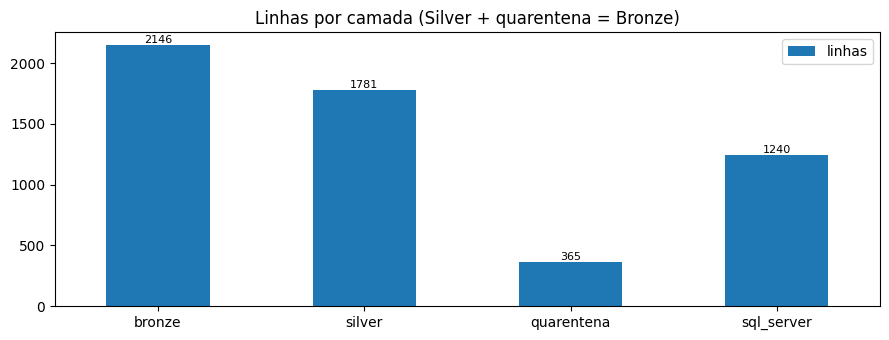

In [0]:
validacao = []
def registrar(grupo, verificacao, resultado, ok, critico=True):
    """Guarda uma verificação para o veredito: falha crítica = ❌ (dado inconsistente); não crítica = ⚠️."""
    situacao = "✅" if ok else ("❌" if critico else "⚠️")
    validacao.append({"grupo": grupo, "verificacao": verificacao, "resultado": str(resultado), "situacao": situacao})
    print(f"{situacao} {grupo} · {verificacao}: {resultado}")


def digital(df):
    """Impressão digital de uma camada: se uma linha se perder ou um valor mudar, algum número muda."""
    return df.agg(F.count("*").alias("linhas"), F.countDistinct("id_pedido").alias("pedidos"),
                  F.countDistinct("bronze_source_file").alias("arquivos"),
                  F.round(F.sum(F.col("valor_total").cast("double")), 2).alias("soma_valor_total")).first().asDict()


contrato = ler_metadata("eda_raw") or {}
bronze, silver, quarentena = (ler_delta(c) if tabela_delta_existe(c) else None for c in (CAMINHO_BRONZE, CAMINHO_SILVER, CAMINHO_QUARANTINE))
checar(bronze is not None and silver is not None, "Bronze e Silver encontradas", "Bronze ou Silver inexistente: rode o pipeline antes")
vazio = {"linhas": 0, "pedidos": 0, "arquivos": 0, "soma_valor_total": 0.0}
camadas = {"bronze": digital(bronze), "silver": digital(silver), "quarentena": digital(quarentena) if quarentena is not None else vazio}
try:
    camadas["sql_server"] = ler_sql_query(f"""SELECT COUNT(*) AS linhas, COUNT(DISTINCT id_pedido) AS pedidos,
        COUNT(DISTINCT arquivo_origem) AS arquivos, ROUND(SUM(valor_total), 2) AS soma_valor_total FROM {nome_tabela_sql(TABELA)}""").first().asDict()
except Exception:
    camadas["sql_server"] = None

# Arquivos do raw sem destino: nem na Bronze, nem anotados como rejeitados
arquivos_raw = set(listar_arquivos_origem())
arquivos_bronze = {r[0] for r in bronze.select("bronze_source_file").distinct().collect()}
sem_destino = arquivos_raw - arquivos_bronze - set(ler_metadata("bronze_ignorados") or {})
soma = lambda *ds: {k: round(sum(float(d[k]) for d in ds), 2) for k in ("linhas", "soma_valor_total")}
sq = soma(camadas["silver"], camadas["quarentena"])

registrar("Reconciliação", "arquivos do raw com destino", f"{len(arquivos_raw) - len(sem_destino)} de {len(arquivos_raw)}", not sem_destino, critico=False)
registrar("Reconciliação", "Bronze = Silver + quarentena (linhas)", f"{camadas['bronze']['linhas']} = {int(sq['linhas'])}", camadas["bronze"]["linhas"] == sq["linhas"])
registrar("Reconciliação", "Bronze = Silver + quarentena (soma de valor_total)", f"{camadas['bronze']['soma_valor_total']} = {sq['soma_valor_total']}",
          abs(float(camadas["bronze"]["soma_valor_total"]) - sq["soma_valor_total"]) <= 0.01 * max(1, camadas["bronze"]["linhas"]))
if camadas["sql_server"]:
    registrar("Reconciliação", "SQL Server = Bronze (linhas)", f"{camadas['sql_server']['linhas']} × {camadas['bronze']['linhas']}",
              camadas["sql_server"]["linhas"] == camadas["bronze"]["linhas"], critico=False)
else:
    registrar("Reconciliação", "SQL Server", "tabela não consultada", False, critico=False)

# ------------------------------ resultado ------------------------------
reconciliacao = pd.DataFrame([{"camada": k, **{c: (None if v is None else v[c]) for c in vazio}} for k, v in camadas.items()])
display(reconciliacao.astype({"linhas": "Int64", "pedidos": "Int64", "arquivos": "Int64", "soma_valor_total": "float"}))
ax = reconciliacao.dropna().plot.bar(x="camada", y="linhas", legend=True, figsize=(9, 3.5), title="Linhas por camada (Silver + quarentena = Bronze)")
ax.bar_label(ax.containers[0], fmt="%.0f", fontsize=8); ax.set_xlabel(""); ax.tick_params(axis="x", rotation=0); plt.tight_layout(); plt.show()

## Etapa 7 — Bronze
**Faz:** confere o contrato de tipos (EDA), a regra 2 (nenhum micro-lote ingerido duas vezes), a existência de cada arquivo no `raw`
e a coerência das partições com `bronze_ingested_at`.
**Valida:** todas as verificações acima.

In [0]:
tipos_bronze = dict(bronze.dtypes)
divergentes = [c for c, t in (contrato.get("schema") or {}).items() if tipos_bronze.get(c) != t]
reingeridos = (bronze.groupBy("bronze_source_file").agg(F.countDistinct("bronze_ingested_at").alias("n")).filter("n > 1").count())
fantasmas = arquivos_bronze - arquivos_raw
particao_errada = bronze.filter((F.col("ano") != F.year("bronze_ingested_at")) | (F.col("mes") != F.month("bronze_ingested_at")) |
                                (F.col("dia") != F.dayofmonth("bronze_ingested_at")) | (F.col("hora") != F.hour("bronze_ingested_at"))).count()

registrar("Bronze", "tipos conforme o contrato da EDA", ", ".join(divergentes) or "todos", not divergentes)
registrar("Bronze", "regra 2: micro-lotes ingeridos mais de uma vez", reingeridos, reingeridos == 0)
registrar("Bronze", "micro-lotes que não existem mais no raw", len(fantasmas), not fantasmas, critico=False)
registrar("Bronze", "linhas com partição diferente de bronze_ingested_at", particao_errada, particao_errada == 0)

✅ Bronze · tipos conforme o contrato da EDA: todos
✅ Bronze · regra 2: micro-lotes ingeridos mais de uma vez: 0
✅ Bronze · micro-lotes que não existem mais no raw: 0
✅ Bronze · linhas com partição diferente de bronze_ingested_at: 0


## Etapa 8 — Silver e quarentena
**Faz:** confere que a Silver só tem pedidos que passam nas regras da planilha (3, 4, 5 e 10), que cada pedido reprovado tem um motivo dessas regras,
que nenhum pedido está nos dois destinos e que a conversão de fuso foi aplicada (a Silver deve ter `dt_pedido` da Bronze + fuso do contrato).
`id_pedido` repetido é só monitorado (⚠️): a planilha não pede deduplicação por pedido.
**Valida:** todas as verificações acima.

In [0]:
FUSO_HORAS = int((contrato.get("fuso") or {}).get("horas_ate_utc", 0))
enum_status = (contrato.get("enums") or {}).get("status_pedido", [])
MOTIVOS_CONHECIDOS = {"regra3_valor_total_nao_positivo", "regra4_dt_pedido_invalida", "regra5_status_fora_do_enum",
                      "regra10_atualizacao_antes_do_pedido"}                       # só as regras da planilha

violacoes = silver.agg(
    F.sum((F.col("valor_total").isNull() | (F.col("valor_total") <= 0)).cast("int")).alias("regra3"),
    F.sum(F.col("dt_pedido").isNull().cast("int")).alias("regra4"),
    F.sum((F.col("status_pedido").isNull() | ~F.col("status_pedido").isin(enum_status)).cast("int")).alias("regra5"),
    F.sum((F.col("dt_ultima_atualizacao_status") < F.col("dt_pedido")).cast("int")).alias("regra10")).first().asDict()
ids_repetidos = silver.groupBy("id_pedido").count().filter("count > 1").count()
chave = ["id_pedido", "bronze_source_file"]
sobreposicao = silver.select(*chave).intersect(quarentena.select(*chave)).count() if quarentena is not None else 0

# Fuso: o mesmo pedido (pedido + micro-lote) na Bronze e na Silver
fuso_errado = (silver.select(*chave, F.col("dt_pedido").alias("dt_silver"))
               .join(bronze.select(*chave, (F.col("dt_pedido") + F.expr(f"INTERVAL {FUSO_HORAS} HOURS")).alias("dt_esperada")), chave)
               .filter(F.col("dt_silver") != F.col("dt_esperada")).count())

for regra, qtd in violacoes.items():
    registrar("Silver", f"aprovados que violam {regra}", qtd or 0, not qtd)
registrar("Silver", "id_pedido repetido (fora da planilha: só monitorado)", ids_repetidos, ids_repetidos == 0, critico=False)
registrar("Silver", f"datas convertidas para UTC (+{FUSO_HORAS} h)", f"{fuso_errado} divergências", fuso_errado == 0)
registrar("Silver", "valor_total em decimal", dict(silver.dtypes).get("valor_total"), str(dict(silver.dtypes).get("valor_total", "")).startswith("decimal"))
registrar("Silver × quarentena", "pedidos nos dois destinos", sobreposicao, sobreposicao == 0)

if quarentena is not None:
    motivos = (quarentena.select(F.explode(F.split(F.coalesce("motivo_quarentena", F.lit("")), ", ")).alias("motivo"))
               .groupBy("motivo").count().orderBy(F.desc("count")).toPandas())
    desconhecidos = sorted(set(motivos["motivo"]) - MOTIVOS_CONHECIDOS)
    registrar("Quarentena", "linhas sem motivo ou com motivo desconhecido", ", ".join(desconhecidos) or "nenhuma", not desconhecidos)
    display(motivos) if len(motivos) else print("Quarentena vazia.")

✅ Silver · aprovados que violam regra3: 0
✅ Silver · aprovados que violam regra4: 0
✅ Silver · aprovados que violam regra5: 0
✅ Silver · aprovados que violam regra10: 0
✅ Silver · id_pedido repetido (fora da planilha: só monitorado): 0
✅ Silver · datas convertidas para UTC (+3 h): 0 divergências
✅ Silver · valor_total em decimal: decimal(12,2)
✅ Silver × quarentena · pedidos nos dois destinos: 0
✅ Quarentena · linhas sem motivo ou com motivo desconhecido: nenhuma


motivo,count
regra5_status_fora_do_enum,234
regra10_atualizacao_antes_do_pedido,125
regra3_valor_total_nao_positivo,23


## Etapa 9 — Gold
**Faz:** confere cada placar (um único `ciclo_id`, ou seja, uma única fotografia), janelas únicas nos históricos, alertas sem repetição,
se a Gold está atualizada em relação à Silver e se a receita por dia bate com a soma dos pedidos aprovados.
**Valida:** todas as verificações acima; Gold desatualizada é ⚠️ (basta rodar a Gold de novo).

In [0]:
existe = lambda nome: tabela_delta_existe(caminho_gold(nome))
gold = lambda nome: ler_delta(caminho_gold(nome))

for nome in ["gold_kpi_volume_pedidos_5min", "gold_kpi_ticket_medio_pagamento", "gold_kpi_taxa_cancelamento_30min", "gold_kpi_receita_dia"]:
    if existe(nome):
        ciclos = gold(nome).select("ciclo_id").distinct().count()
        registrar("Gold", f"{nome}: uma única fotografia", f"{ciclos} ciclo_id", ciclos == 1)
for nome in ["gold_hist_volume_pedidos_5min", "gold_hist_taxa_cancelamento_30min"]:
    if existe(nome):
        h = gold(nome)
        repetidas = h.count() - h.select("janela_inicio").distinct().count()
        registrar("Gold", f"{nome}: janelas repetidas", repetidas, repetidas == 0)
if existe("gold_alertas"):
    a = gold("gold_alertas")
    repetidos = a.count() - a.select("chave").distinct().count()
    registrar("Gold", "gold_alertas: alertas publicados mais de uma vez", repetidos, repetidos == 0)

# Atualização: o pedido mais recente considerado pela Gold deve ser o mais recente da Silver
mais_recente_silver = silver.agg(F.max(F.col("dt_pedido") - F.expr("INTERVAL 3 HOURS"))).first()[0]
referencia_gold = pd.to_datetime((ler_metadata("gold_controle") or {}).get("referencia"), errors="coerce")
registrar("Gold", "considera o pedido mais recente da Silver", f"Gold {referencia_gold} · Silver {pd.Timestamp(mais_recente_silver)}",
          pd.notna(referencia_gold) and referencia_gold >= pd.Timestamp(mais_recente_silver), critico=False)

# Receita por dia (Brasília): placar da Gold × soma dos aprovados na Silver
if existe("gold_kpi_receita_dia"):
    gold_dia = gold("gold_kpi_receita_dia").select(F.to_date("data").alias("dia"), "receita_acumulada")
    silver_dia = (silver.groupBy(F.to_date(F.col("dt_pedido") - F.expr("INTERVAL 3 HOURS")).alias("dia"))
                  .agg(F.round(F.sum(F.col("valor_total").cast("double")), 2).alias("receita_silver")))
    receita = gold_dia.join(silver_dia, "dia", "left").withColumn("diferenca", F.round(F.col("receita_acumulada") - F.col("receita_silver"), 2)).toPandas()
    dias_divergentes = int((receita["diferenca"].abs() > 0.01).sum())
    registrar("Gold", "receita por dia = soma dos aprovados na Silver", f"{len(receita) - dias_divergentes} de {len(receita)} dias",
              dias_divergentes == 0, critico=False)
    display(receita.sort_values("dia", ascending=False)) if len(receita) else None

✅ Gold · gold_kpi_volume_pedidos_5min: uma única fotografia: 1 ciclo_id
✅ Gold · gold_kpi_ticket_medio_pagamento: uma única fotografia: 1 ciclo_id
✅ Gold · gold_kpi_taxa_cancelamento_30min: uma única fotografia: 1 ciclo_id
✅ Gold · gold_kpi_receita_dia: uma única fotografia: 1 ciclo_id
✅ Gold · gold_hist_volume_pedidos_5min: janelas repetidas: 0
✅ Gold · gold_hist_taxa_cancelamento_30min: janelas repetidas: 0
✅ Gold · gold_alertas: alertas publicados mais de uma vez: 0
✅ Gold · considera o pedido mais recente da Silver: Gold 2026-10-08 16:21:32.734094 · Silver 2026-10-08 16:21:32.734094
✅ Gold · receita por dia = soma dos aprovados na Silver: 6 de 6 dias


dia,receita_acumulada,receita_silver,diferenca
2026-10-08,173086.61,173086.61,0.0
2026-10-07,53675.91,53675.91,0.0
2026-10-05,30318.54,30318.54,0.0
2026-10-04,199.79,199.79,0.0
2026-10-03,32450.2,32450.2,0.0
2026-10-01,187632.2,187632.2,0.0


## Etapa 10 — Integridade referencial (informativo)
**Faz:** procura os `id_cliente` dos pedidos aprovados na tabela de clientes da squad (`squad2/bronze/ecommerce_clientes`, de outra dupla, só leitura)
e mede quantos pedidos usam o próprio `id_pedido` como `id_cliente`, um padrão do gerador.
**Valida:** nada bloqueia: são achados para a conversa com o Geovany e com a dupla de clientes.

In [0]:
CAMINHO_CLIENTES = f"{BASE_SQUAD}/bronze/ecommerce_clientes"
ids_iguais = silver.agg(F.round(F.avg((F.col("id_cliente") == F.col("id_pedido")).cast("int")) * 100, 1)).first()[0]
registrar("Referencial", "pedidos com id_cliente igual ao id_pedido", f"{ids_iguais}%", not ids_iguais, critico=False)

if tabela_delta_existe(CAMINHO_CLIENTES) and "id_cliente" in ler_delta(CAMINHO_CLIENTES).columns:
    clientes = ler_delta(CAMINHO_CLIENTES).select("id_cliente").distinct()
    pedidos_clientes = silver.select("id_cliente").distinct()
    encontrados = pedidos_clientes.join(clientes, "id_cliente").count()
    total = pedidos_clientes.count()
    registrar("Referencial", "clientes dos pedidos encontrados em ecommerce_clientes", f"{encontrados} de {total}", encontrados == total, critico=False)
else:
    registrar("Referencial", "tabela ecommerce_clientes da squad", "não encontrada", False, critico=False)

⚠️ Referencial · pedidos com id_cliente igual ao id_pedido: 10.6%
⚠️ Referencial · clientes dos pedidos encontrados em ecommerce_clientes: 109 de 1185


## Etapa 11 — Veredito da validação
**Faz:** reúne todas as verificações das Etapas 6 a 10.
**Valida:** sem nenhum ❌, os dados enviados estão consistentes; ⚠️ são pendências de sincronização (rodar uma camada de novo) ou achados informativos.

In [0]:
veredito = pd.DataFrame(validacao, columns=["grupo", "verificacao", "resultado", "situacao"])
contagem = veredito["situacao"].value_counts().to_dict()

# ------------------------------ validação ------------------------------
checar(contagem.get("❌", 0) == 0, f"DADOS VALIDADOS: {contagem.get('✅', 0)} verificações ok, {contagem.get('⚠️', 0)} avisos",
       f"{contagem.get('❌', 0)} inconsistências nos dados: veja as linhas com ❌", parar=False)

# ------------------------------ resultado ------------------------------
display(veredito.sort_values("situacao", key=lambda s: s.map({"❌": 0, "⚠️": 1, "✅": 2}), ignore_index=True))

✅ DADOS VALIDADOS: 24 verificações ok, 4 avisos


grupo,verificacao,resultado,situacao
Reconciliação,arquivos do raw com destino,339 de 340,⚠️
Referencial,pedidos com id_cliente igual ao id_pedido,10.6%,⚠️
Reconciliação,SQL Server = Bronze (linhas),1240 × 2146,⚠️
Referencial,clientes dos pedidos encontrados em ecommerce_clientes,109 de 1185,⚠️
Bronze,tipos conforme o contrato da EDA,todos,✅
Gold,receita por dia = soma dos aprovados na Silver,6 de 6 dias,✅
Gold,considera o pedido mais recente da Silver,Gold 2026-10-08 16:21:32.734094 · Silver 2026-10-08 16:21:32.734094,✅
Gold,gold_alertas: alertas publicados mais de uma vez,0,✅
Gold,gold_hist_taxa_cancelamento_30min: janelas repetidas,0,✅
Gold,gold_hist_volume_pedidos_5min: janelas repetidas,0,✅
